In [276]:
from pyCicero import preprocess
from pyCicero import run_cicero
from pyCicero import correlate_peaks

In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
from scipy.io import mmread

In [3]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, message=".*force_all_finite.*")

In [63]:
counts = mmread("../../05_2025_raw_data/ATAC/05_02_2025_neuronal_FMatrix.mtx").T.tocsr()

In [92]:
obs_names = pd.read_csv("../../05_2025_raw_data/ATAC/05_02_2025_neuronal_FMatrix_Col_Names.csv", index_col=0)
vars = pd.read_csv("../../05_2025_raw_data/ATAC/05_02_2025_neuronal_FMatrix_Row_Names.csv", index_col=0)
vars.index = ["merged-id" + str(x) for x in vars.index.values]
obs = pd.read_csv("../../05_2025_raw_data/ATAC/05_02_2025_Meta_Data.csv", index_col=0)
obs = obs.reindex(obs_names["x"])

In [65]:
counts.data[counts.data > 0] = 1
shuffle = False
if shuffle:
    rng = np.random.RandomState(0)
    counts = counts[:, rng.permutation(counts.shape[1])]

In [93]:
adata = sc.AnnData(counts, obs = obs, var = vars)

In [94]:
adata = adata[:,["chr" in x for x in vars["x"].values]] #subset adata to only have chromosomes that contain "chr" 

In [ ]:
annotations_neuronal_atac = pd.read_csv("../../05_2025_Merged_ATAC_Neuronal_Homer_annotations.txt", sep = "\t")
annotated_vars = annotations_neuronal_atac.set_index(annotations_neuronal_atac.columns[0]).reindex(adata.var.index)

In [96]:
adata.var = annotated_vars
adata.var.insert(3, "Mean", (adata.var["Start"] + adata.var["End"])/2) #need to have a column named mean 

In [43]:
adata = preprocess.preprocess_cicero(adata)

preprocess.py: 2025-05-05 21:20:13 WARNING  Counts layers not found. Coppying X to counts
preprocess.py: 2025-05-05 21:20:13 INFO     Estimaing Size Factors and Normalizing Data
preprocess.py: 2025-05-05 21:20:34 INFO     Finished Size Factors and Normallization storing normalized sparse matrix into 'data'
preprocess.py: 2025-05-05 21:20:34 INFO     Running TF-IDF
preprocess.py: 2025-05-05 21:20:38 INFO     Finsihed TF-IDF
preprocess.py: 2025-05-05 21:20:38 INFO     Running TruncatedSVD
preprocess.py: 2025-05-05 21:23:41 INFO     Finsihed TruncatedSVD
preprocess.py: 2025-05-05 21:23:41 INFO     Running UMAP
preprocess.py: 2025-05-05 21:23:43 INFO     Finsihed UMAP


In [44]:
cicero_adata = preprocess.make_cicero_adata(adata, k = 50)

preprocess.py: 2025-05-05 21:23:43 INFO     Using adata OBSM X_umap to agregate cells
preprocess.py: 2025-05-05 21:23:43 INFO     Calculating overlap
preprocess.py: 2025-05-05 21:23:44 INFO     Generating Pseudobulk cicero observations with seed: 0 and k: 50
preprocess.py: 2025-05-05 21:23:53 INFO     Reached Maximum itterations in pseudobulk observation generation. Consider increasing 'max_itterations'
preprocess.py: 2025-05-05 21:23:53 INFO     Found 3240 good choices
preprocess.py: 2025-05-05 21:23:53 INFO     Finished calculating overlap
preprocess.py: 2025-05-05 21:23:53 INFO     Aggregating Cells
preprocess.py: 2025-05-05 21:24:33 INFO     Finished Aggregating Cells


In [ ]:
cons = run_cicero.run_cicero(cicero_adata)

run_cicero.py: 2025-05-05 21:25:36 INFO     Generating Windows
run_cicero.py: 2025-05-05 21:25:36 INFO     Starting distance_parameter_estimation
run_cicero.py: 2025-05-05 21:28:49 INFO     Starting multiprocessing pool for estimate_distance_parameter_parallel with 96 processes
run_cicero.py: 2025-05-05 21:30:31 INFO     Finished distance_parameter_estimation
run_cicero.py: 2025-05-05 21:30:31 INFO     Starting generate_cicero_models
run_cicero.py: 2025-05-05 21:32:02 INFO     Starting Cicero with 96 processes
run_cicero.py: 2025-05-05 21:32:52 INFO     Finished generate_cicero_models
run_cicero.py: 2025-05-05 21:32:53 INFO     Starting assemble_connections
run_cicero.py: 2025-05-05 21:33:46 INFO     Finished assemble_connections


In [25]:
cons[np.abs(cons["coaccess_score"]) > 0.2].head()

,Peak1,Peak2,coaccess_score
195,merged-id1000,merged-id1001,0.326215
268,merged-id1000,merged-id999,0.259521
479,merged-id100000,merged-id99999,0.546932
1236,merged-id100007,merged-id100041,0.246989
1736,merged-id100010,merged-id99985,0.214190


In [ ]:
import pickle
cons_shuffled = pickle.load(open("cons_shuffled.pickle", "rb"))

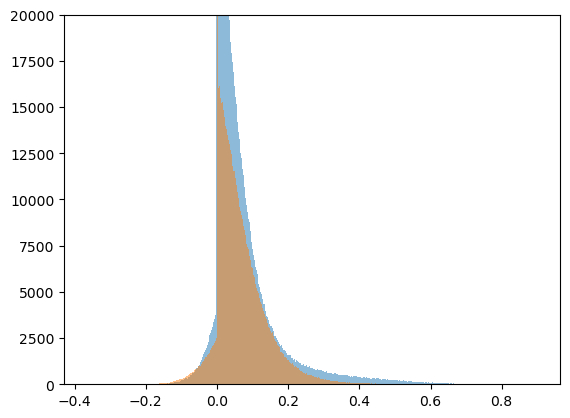

In [55]:
import matplotlib.pyplot as plt
plt.hist(cons["coaccess_score"], bins = 500, label = "Non-Shuffled", alpha = 0.5)
plt.hist(cons_shuffled["coaccess_score"], bins = 500, label = "Shuffled", alpha = 0.5)
plt.ylim((0, 20000))
plt.show()

In [128]:
rna_adata = sc.read_h5ad("../../../spinal_cord_main/03_2025_Objects/Figure 1/03_2025_main_adata.h5ad")
mapping_dict = pd.read_csv("../../translated_valid_neuronal_barcodes_atac.csv", index_col=0)["barcode"].to_dict()

In [ ]:
rna_adata = rna_adata[rna_adata.obs_names.isin(mapping_dict.keys())].raw.to_adata() #make sure the names of the ATAC and RNA are the same 
rna_adata.obs_names = list(map(mapping_dict.get, rna_adata.obs_names))
atac_adata = adata #use the original adata if not agregating

In [347]:
cons_correlated = correlate_peaks.correlate_peaks(cons, rna_adata, atac_adata)

correlate_peaks.py: 2025-05-06 01:18:17 INFO     Generating Peak to Links
correlate_peaks.py: 2025-05-06 01:18:18 INFO     Finished generating Peak to Links
correlate_peaks.py: 2025-05-06 01:18:18 WARNING  rna and atac adata do not share the same obs_names. Trying to fix by computing union of cell names
correlate_peaks.py: 2025-05-06 01:18:18 WARNING  Subsetting to 96.88% of original observations
correlate_peaks.py: 2025-05-06 01:18:20 INFO     Runnign Correlation with pearson correlation
correlate_peaks.py: 2025-05-06 01:18:22 INFO     Finsihed running Correlation
correlate_peaks.py: 2025-05-06 01:18:22 INFO     Adding Links and Correlation to Cons
correlate_peaks.py: 2025-05-06 01:18:22 INFO     Finished


In [ ]:
#If you run with aggregation pass cicero_adata instead of atac_adata
cons_correlated_aggregate = correlate_peaks.correlate_peaks(cons, rna_adata, cicero_adata, aggregate = True)

correlate_peaks.py: 2025-05-06 01:23:21 INFO     Aggregating rna_adata to match cicero_adata
correlate_peaks.py: 2025-05-06 01:23:24 INFO     Generating Peak to Links
correlate_peaks.py: 2025-05-06 01:23:24 INFO     Finished generating Peak to Links
correlate_peaks.py: 2025-05-06 01:23:26 INFO     Runnign Correlation with pearson correlation
correlate_peaks.py: 2025-05-06 01:23:27 INFO     Finsihed running Correlation
correlate_peaks.py: 2025-05-06 01:23:27 INFO     Adding Links and Correlation to Cons
correlate_peaks.py: 2025-05-06 01:23:27 INFO     Finished


In [359]:
print(f"Mean Abs Correlation without Aggregation: {np.mean(np.abs(cons_correlated['RNA_Correlations'])):.4f}")
print(f"Mean Abs Correlation With Aggregation: {np.mean(np.abs(cons_correlated_aggregate['RNA_Correlations'])):.4f}")

Mean Abs Correlation without Aggregation: 0.0455
Mean Abs Correlation With Aggregation: 0.1443
